In [1]:
import random
import dill 
import datetime as dt
import glob 
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import pandas as pd
import scipy.spatial as spatial
import sys 
wd=".."
sys.path.append(wd+'//CPN//')
import numpy as np 
import statsmodels.api as sm
from tqdm import tqdm_notebook, tqdm
import brokenaxes
import math
import os
from analysis_misc_functions import *

In [2]:
group_heading_variation = [10, "swarming", "milling"]
list_of_folder_ids_all_heading_vars= []
list_of_folder_ids_array_version_all_heading_vars= []
for heading_var in group_heading_variation:
    results_folder = wd+"/simulations/effect_of_heading_plus_radial/store_results_poster/"+str(heading_var)+"/"
    list_of_folder_ids= glob.glob(results_folder+"*", recursive=True)
    list_of_folder_ids= np.sort(list_of_folder_ids)
    # # glob.glob(results_folder+"*")
    def clean_string_and_int_labels(input):
        try:
            output= float(input)
        except ValueError:
            output= input[1:-1]
            if output=='flocking':
                output='milling'
        return output

    list_of_folder_ids= [str(i) for i in list_of_folder_ids]
    # list_of_folder_ids
    list_of_folder_ids_array_version= [i[len(results_folder):] for i in list_of_folder_ids]
    list_of_folder_ids_array_version= [i.split(",") for i in list_of_folder_ids_array_version]
    list_of_folder_ids_array_version= [(n[0][1:],n[1][1:], n[2][1:-1]) for n in list_of_folder_ids_array_version]
    list_of_folder_ids_array_version= [(float(n[0]), float(n[1]), clean_string_and_int_labels(n[2])) for n in list_of_folder_ids_array_version]


    list_of_folder_ids_all_heading_vars.append(list_of_folder_ids)
    list_of_folder_ids_array_version_all_heading_vars.append(list_of_folder_ids_array_version)
    
folder_id= list_of_folder_ids_all_heading_vars[2][0]
all_results = glob.glob(folder_id+'/*.simresults')
some_results = random.sample(all_results, int(len(all_results)*1.0))
print(all_results)

["../simulations/effect_of_heading_plus_radial/store_results_poster/milling/(0, 0, 'milling')/heading_plus_radial_milling_7fd4554f-8032-48b6-8312-aa24311a51d6_924124393_.simresults", "../simulations/effect_of_heading_plus_radial/store_results_poster/milling/(0, 0, 'milling')/heading_plus_radial_milling_5f778316-2c36-4af4-b701-25df45933c57_222010746_.simresults", "../simulations/effect_of_heading_plus_radial/store_results_poster/milling/(0, 0, 'milling')/heading_plus_radial_milling_18f9fdf2-5481-4c0b-bc01-deb6c22b80d8_80085397_.simresults", "../simulations/effect_of_heading_plus_radial/store_results_poster/milling/(0, 0, 'milling')/heading_plus_radial_milling_7959f3b1-9423-4a99-b271-a2090c4c49bb_404028835_.simresults", "../simulations/effect_of_heading_plus_radial/store_results_poster/milling/(0, 0, 'milling')/heading_plus_radial_milling_feeae5b3-8398-4851-ac38-1324fc2fa26e_236951556_.simresults", "../simulations/effect_of_heading_plus_radial/store_results_poster/milling/(0, 0, 'milling

In [3]:
extraction_fns = [get_num_echoes_heard, get_group_size, get_furthest_bat2bat_distance,
                 get_nearest_neighbour_distances, get_detection_distance, get_run_uuid,
                  get_run_random_seed,make_paramset_id, extract_parameter_values,
                 get_echo_levels, get_detection_azimuth]
keyword_arguments = {'nearest_nbrs':3}
keyword_arguments['variables_to_extract'] = ['heading_variation', 'echocall_duration','atmospheric_attenuation','min_spacing','source_level',
                        'interpulse_interval', 'implement_shadowing',
                                            ]
what_to_do = input('Do you want to "rerun" from scratch or 2, "reanalyse" from previous data')
task_type= input('What type of analysis is this?')

In [4]:
# if what_to_do == 'rerun':
store_info= {}
for heading_var in group_heading_variation:
    index= group_heading_variation.index(heading_var)
    list_of_folder_ids= list_of_folder_ids_all_heading_vars[index]; list_of_folder_ids_array_version= list_of_folder_ids_array_version_all_heading_vars[index]
    array_containing_all_simulation_datasets_raw = []
    iterant=0
    yyyymmdd = dt.datetime.now()
    timestamp = str([yyyymmdd.year,yyyymmdd.month,yyyymmdd.day,yyyymmdd.hour])
    make_dir(task_type+'_data'+timestamp+"/")
    for folder_id in list_of_folder_ids:
        all_results = glob.glob(folder_id+'/*.simresults')
        some_results =random.sample(all_results, int(len(all_results)*1.0))
        
        %time extracted_simdata = Parallel(n_jobs=4)(delayed(load_and_extract)(each, extraction_fns, **keyword_arguments) for each in tqdm(some_results))
        # print(extracted_simdata)
        echoes_heard = []
        group_size = []
        group_diameter = []
        nearest_3nbrs = []
        nbr_detection_range = []
        uuid = []
        seed = []
        param_ids = []
        parameter_values = []
        echo_levels = []
        detection_angle = []
        for each in extracted_simdata:
            for variable, list_to_append in zip(each, [echoes_heard, group_size, group_diameter,
                                                    nearest_3nbrs, nbr_detection_range,
                                                    uuid, seed, param_ids, parameter_values,
                                                    echo_levels, detection_angle]):
                list_to_append.append(variable)
        simulation_data = pd.DataFrame(data = {'nbrs_detected':echoes_heard,
                                        'group_size':group_size,
                                        'group_diameter':group_diameter,
                                        'nearest_neighbour_distance':nearest_3nbrs,
                                        'nbrs_detected_distance':nbr_detection_range,
                                        'uuid':uuid,
                                        'seed':seed,
                                        'paramset_id':param_ids,
                                        'parameters_joint':parameter_values,
                                        'echo_levels':echo_levels,
                                        'detection_azimuth':detection_angle})
        column_names = keyword_arguments['variables_to_extract']

        for each in column_names:
            simulation_data[each] = np.nan

        %time simulation_data = simulation_data.apply(split_parameters_joint_to_separate_columns, 1, col_names=column_names)    
        

        simulation_data["focal_bat"]= len(simulation_data)*[list_of_folder_ids_array_version[iterant]]

        ##### thanks to https://realpython.com/fast-flexible-pandas/#but-i-heard-that-pandas-is-slow
        # data_store = pd.HDFStore(task_type+'_data'+timestamp+'/'+folder_id+'.h5')
        # data_store['simulation_data'] = simulation_data
        # data_store.close()

        array_containing_all_simulation_datasets_raw.append(simulation_data)
        iterant+=1
    store_info[heading_var]= array_containing_all_simulation_datasets_raw
        
# if what_to_do == 'reanalyse':
#     # show all datasets in the folder
#     data_stores_in_folder = glob.glob(task_type+'_*]')

#     datastores_by_index = pd.DataFrame(data={'data_stores':data_stores_in_folder})
#     print(datastores_by_index)
#     # user-inputs dataset choice:
#     which_dataset = int(input('Give the index of the dataset you want to'))
#     print()
#     # load a pre-exisiting dataset
#     #load the saved data 
#     list_of_h5_files_in_folder= making_glob_work_properly(datastores_by_index["data_stores"][which_dataset])
#     # print(list_of_h5_files_in_folder); print("./"+datastores_by_index["data_stores"][which_dataset]+'/*')
#     array_containing_all_simulation_datasets_raw = []
#     list_of_folder_ids, list_of_folder_ids_array_version= run_while_reanalysis_to_change_folder_ids(list_of_h5_files_in_folder)
#     for h5_file in list_of_h5_files_in_folder:
#         data_load = pd.HDFStore("./"+datastores_by_index["data_stores"][which_dataset]+'/'+h5_file)
#         simulation_data = data_load['simulation_data']
#         array_containing_all_simulation_datasets_raw.append(simulation_data)
#         data_load.close()

# else:
#     raise IOError('Invalid input given!!')

100%|██████████| 300/300 [00:01<00:00, 281.61it/s]


CPU times: user 51.4 ms, sys: 9.37 ms, total: 60.7 ms
Wall time: 1.21 s
CPU times: user 16.4 ms, sys: 0 ns, total: 16.4 ms
Wall time: 16.4 ms


100%|██████████| 100/100 [00:00<00:00, 1542.53it/s]


CPU times: user 16.4 ms, sys: 1.07 ms, total: 17.5 ms
Wall time: 124 ms
CPU times: user 5.76 ms, sys: 0 ns, total: 5.76 ms
Wall time: 5.77 ms


100%|██████████| 100/100 [00:00<00:00, 1576.60it/s]


...

CPU times: user 12.7 ms, sys: 4.16 ms, total: 16.8 ms
Wall time: 113 ms
CPU times: user 5.95 ms, sys: 0 ns, total: 5.95 ms
Wall time: 5.89 ms


100%|██████████| 100/100 [00:00<00:00, 1273.28it/s]


CPU times: user 14.9 ms, sys: 2.06 ms, total: 16.9 ms
Wall time: 153 ms
CPU times: user 5.75 ms, sys: 0 ns, total: 5.75 ms
Wall time: 5.76 ms


100%|██████████| 100/100 [00:00<00:00, 1146.71it/s]


CPU times: user 17.8 ms, sys: 1.15 ms, total: 18.9 ms
Wall time: 164 ms
CPU times: user 6.64 ms, sys: 0 ns, total: 6.64 ms
Wall time: 6.65 ms


In [5]:
store_info["milling"][3]["focal_bat"]
store_info["milling"][3]["group_size"]
array= ["intermediate+" if i==30 else "edge+" for i in list(store_info["milling"][3]["group_size"])]
print(array)
store_info["milling"][2]["group_size"]

['edge+', 'edge+', 'edge+', 'intermediate+', 'intermediate+', 'edge+', 'intermediate+', 'edge+', 'intermediate+', 'intermediate+', 'intermediate+', 'edge+', 'intermediate+', 'edge+', 'intermediate+', 'edge+', 'intermediate+', 'edge+', 'intermediate+', 'intermediate+', 'edge+', 'intermediate+', 'edge+', 'intermediate+', 'edge+', 'edge+', 'edge+', 'intermediate+', 'edge+', 'edge+', 'intermediate+', 'intermediate+', 'edge+', 'edge+', 'intermediate+', 'edge+', 'intermediate+', 'edge+', 'edge+', 'edge+', 'intermediate+', 'edge+', 'intermediate+', 'intermediate+', 'edge+', 'edge+', 'intermediate+', 'intermediate+', 'intermediate+', 'edge+', 'edge+', 'edge+', 'edge+', 'edge+', 'intermediate+', 'edge+', 'intermediate+', 'intermediate+', 'edge+', 'intermediate+', 'edge+', 'intermediate+', 'edge+', 'intermediate+', 'intermediate+', 'intermediate+', 'intermediate+', 'intermediate+', 'edge+', 'edge+', 'intermediate+', 'intermediate+', 'intermediate+', 'intermediate+', 'edge+', 'intermediate+', 'ed

0     10
1     10
2     10
3     10
4     10
      ..
95    10
96    10
97    10
98    10
99    10
Name: group_size, Length: 100, dtype: int64

In [6]:
store_info_cleaned= {}
subset= [10,"milling", "swarming"]
for key in subset:
    print(key)
    array_containing_all_simulation_datasets_raw= store_info[key]
    array_containing_all_simulation_datasets=[]
    array_containing_labels= []
    for simulation_data in array_containing_all_simulation_datasets_raw:
        try:
            if simulation_data["focal_bat"][0][2]==key:
                if simulation_data["focal_bat"][0][0:2] == (0.0,0.0):
                    simulation_data["categorical_radial_d"] = "center"
                    
                if simulation_data["focal_bat"][0][0:2] == (3.0, np.pi/2):
                    simulation_data["categorical_radial_d"] = "intermediate+"
                if simulation_data["focal_bat"][0][0:2] == (3.0, 3*np.pi/2):
                    simulation_data["categorical_radial_d"] = "intermediate-"
                if simulation_data["focal_bat"][0][0:2] == (6.0, np.pi/2):
                    simulation_data["categorical_radial_d"] = "edge+"
                if simulation_data["focal_bat"][0][0:2] == (6.0, 3*np.pi/2):
                    simulation_data["categorical_radial_d"] = "edge-"
                    
                if simulation_data["focal_bat"][0][0:2] == (4.0, np.pi/2):
                    simulation_data["categorical_radial_d"] = "edge+"
                if simulation_data["focal_bat"][0][0:2] == (4.0, 3*np.pi/2):
                    simulation_data["categorical_radial_d"] = "edge-" 
                    
                if simulation_data["focal_bat"][0][0:2] == (1.0, np.pi/2):
                    simulation_data["categorical_radial_d"] = "intermediate+"   
                if simulation_data["focal_bat"][0][0:2] == (1.0, 3*np.pi/2):
                    simulation_data["categorical_radial_d"] = "intermediate-"
                    
                if simulation_data["focal_bat"][0][0:2] == (2.0, np.pi/2):
                    array= ["intermediate+" if i==30 else "edge+" for i in list(simulation_data["group_size"])]
                    simulation_data["categorical_radial_d"] = array
                if simulation_data["focal_bat"][0][0:2] == (2.0, 3*np.pi/2):
                    array= ["intermediate-" if i==30 else "edge-" for i in list(simulation_data["group_size"])]
                    simulation_data["categorical_radial_d"] = array     
                print(simulation_data["focal_bat"][0])    
                array_containing_all_simulation_datasets.append(simulation_data)
                array_containing_labels.append(simulation_data["focal_bat"][0])
        except KeyError:
            continue
    store_info_cleaned[key]= array_containing_all_simulation_datasets
    array_containing_labels= np.array(array_containing_labels)


    unique_angles_in_dataset= np.unique(array_containing_labels[:,1])
    list_containing_simulated_data_sorted_by_angles= {}
    for angle in unique_angles_in_dataset:
        list_containing_simulated_data_sorted_by_angles[angle]= []
        sublist_true_false_labels= array_containing_labels[:,1]==angle
        sublist_given_angle= passing_true_false_indices_through_lists(array_containing_all_simulation_datasets, sublist_true_false_labels)
        list_containing_simulated_data_sorted_by_angles[angle].append(sublist_given_angle)



    for angle in list_containing_simulated_data_sorted_by_angles.keys():
            subset_given_angle= list_containing_simulated_data_sorted_by_angles[angle][0]
            for simulation_data in subset_given_angle:
                    data_by_groupsize = simulation_data.groupby(['group_size'])
                    nbrs_detected_data = {}
                    nbrs_detected_data['num_nbrs'] = []
                    nbrs_detected_data['median_num_nbrs'] = []
                    nbrs_detected_data['90%ile_num_nbrs'] = []
                    groupsizes= []
                    for groupsize, dataframe in data_by_groupsize:
                            groupsizes.append(groupsize)
                            nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
                            nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
                            nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))

                    breakup_x_axis  = np.arange(1,len(groupsizes)+1)+0.5
                    nbrs_detected_data['median_num_nbrs']


10
(0.0, 0.0, 10.0)
(1.0, 1.5707963267948966, 10.0)
(1.0, 4.71238898038469, 10.0)
(2.0, 1.5707963267948966, 10.0)
(2.0, 4.71238898038469, 10.0)
(3.0, 1.5707963267948966, 10.0)
(3.0, 4.71238898038469, 10.0)
(4.0, 1.5707963267948966, 10.0)
(4.0, 4.71238898038469, 10.0)
(6.0, 1.5707963267948966, 10.0)
(6.0, 4.71238898038469, 10.0)
milling
(0.0, 0.0, 'milling')
(1.0, 1.5707963267948966, 'milling')
(1.0, 4.71238898038469, 'milling')
(2.0, 1.5707963267948966, 'milling')
(2.0, 4.71238898038469, 'milling')
(3.0, 1.5707963267948966, 'milling')
(3.0, 4.71238898038469, 'milling')
(4.0, 1.5707963267948966, 'milling')
(4.0, 4.71238898038469, 'milling')
(6.0, 1.5707963267948966, 'milling')
(6.0, 4.71238898038469, 'milling')
swarming
(0.0, 0.0, 'swarming')
(1.0, 1.5707963267948966, 'swarming')
(1.0, 4.71238898038469, 'swarming')
(2.0, 1.5707963267948966, 'swarming')
(2.0, 4.71238898038469, 'swarming')
(3.0, 1.5707963267948966, 'swarming')
(3.0, 4.71238898038469, 'swarming')
(4.0, 1.5707963267948966, 

In [7]:
i=-1
print(store_info[10][i]["categorical_radial_d"][0])
print(store_info[10][i]["focal_bat"][0])

edge-
(6.0, 4.71238898038469, 10.0)


# Verticle transect

moving from $(0.75, \frac {3pi}{2})$ to $(0.75, \frac {pi}{2})$ [r, theta] is similar to moving in a ($x=0$) transect centered at the centermost bat.
Note: All the heading vectors are in 90 degree direction ( $\pm$ 10 degree)

In [8]:
array_containing_all_simulation_datasets[0]["focal_bat"]


0      (0.0, 0.0, swarming)
1      (0.0, 0.0, swarming)
2      (0.0, 0.0, swarming)
3      (0.0, 0.0, swarming)
4      (0.0, 0.0, swarming)
               ...         
295    (0.0, 0.0, swarming)
296    (0.0, 0.0, swarming)
297    (0.0, 0.0, swarming)
298    (0.0, 0.0, swarming)
299    (0.0, 0.0, swarming)
Name: focal_bat, Length: 300, dtype: object

In [9]:
key= "swarming"
transect_subsets= [[6.0, 3*np.pi/2, key],[5.0, 3*np.pi/2, key],[4.0, 3*np.pi/2, key],[3.0, 3*np.pi/2, key],[2.0, 3*np.pi/2, key],[1.0, 3*np.pi/2, key],[1.0, np.pi/2, key],[2.0, np.pi/2, key], [3.0, np.pi/2, key], [4.0, np.pi/2, key], [5.0, np.pi/2, key], [6.0, np.pi/2, key]]
transect_subsets= [tuple(i) for i in transect_subsets]
iterant_transect=0
sublist_of_simulation_data_intransect=[]
for r_theta in transect_subsets:
    for simulation_data in array_containing_all_simulation_datasets:
        if simulation_data["focal_bat"][0]==r_theta:
            sublist_of_simulation_data_intransect.append(simulation_data)    

sign_based_on_distance_from_centermost_point= [-1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1]     
group_sizes= [5,10,20,30,50,75]

In [10]:
# sublist_of_simulation_data_intransect_across_heading_var= {}
# group_heading_variation = [10, "swarming", "milling"]
# for heading_var in group_heading_variation:
#     sublist_of_simulation_data_intransect=[]
#     array_containing_all_simulation_datasets= store_info_cleaned[heading_var]
#     key= heading_var
#     transect_subsets= [[6.0, 3*np.pi/2, key],[5.0, 3*np.pi/2, key],[4.0, 3*np.pi/2, key],[3.0, 3*np.pi/2, key],[2.0, 3*np.pi/2, key],[1.0, 3*np.pi/2, key],[1.0, np.pi/2, key],[2.0, np.pi/2, key], [3.0, np.pi/2, key], [4.0, np.pi/2, key], [5.0, np.pi/2, key], [6.0, np.pi/2, key]]
#     transect_subsets= [tuple(i) for i in transect_subsets]

#     for r_theta in transect_subsets:
#         for simulation_data in array_containing_all_simulation_datasets:
#             if simulation_data["focal_bat"][0]==r_theta:
#                 sublist_of_simulation_data_intransect.append(simulation_data)    
#     sublist_of_simulation_data_intransect_across_heading_var[heading_var]= sublist_of_simulation_data_intransect

In [11]:
store_info_cleaned[10][0]["categorical_radial_d"]

0      center
1      center
2      center
3      center
4      center
        ...  
295    center
296    center
297    center
298    center
299    center
Name: categorical_radial_d, Length: 300, dtype: object

separate the violin plots out for different group sizes to see clear differences between distance from center


/tmp/ipykernel_1702609/1524660129.py:20: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  dataframe = simulation_data.groupby(['group_size']).get_group(group_size)
/tmp/ipykernel_1702609/1524660129.py:20: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  dataframe = simulation_data.groupby(['group_size']).get_group(group_size)
/tmp/ipykernel_1702609/1524660129.py:20: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  dataframe = simulation_data.groupby(['group_size']).get_group(group_size)


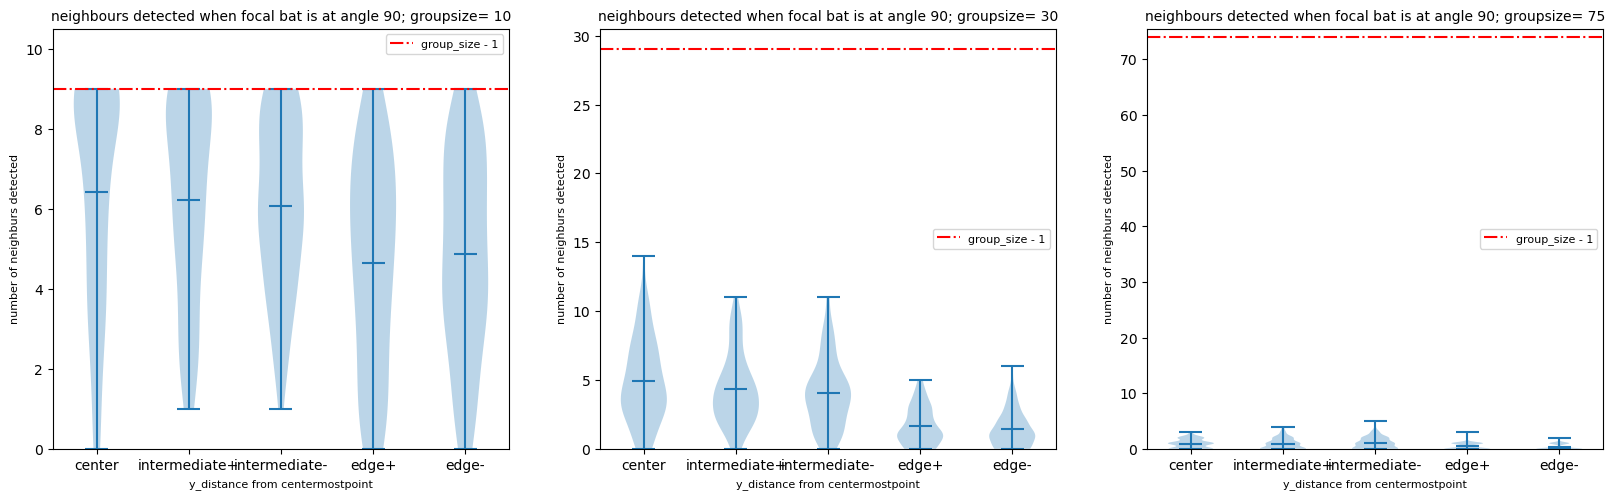

In [12]:
colors=["blue", "red", "green", "black", "pink", "cyan", "yellow"]

# fig, axs = plt.subplots(1,1, figsize=(27,9))
i=0; 
number_of_columns=3; number_of_rows= int(np.ceil(len(group_sizes)/number_of_columns))
plt.figure(figsize=(20,12))
sublist_of_simulation_data_intransect= store_info_cleaned["swarming"]
group_sizes= [10, 30, 75]
for group_size in group_sizes:
    nbrs_detected_data = {}
    nbrs_detected_data['num_nbrs'] = []
    nbrs_detected_data['median_num_nbrs'] = []
    nbrs_detected_data['90%ile_num_nbrs'] = []
    
    x_ticks= []; iterant_sign=-1
    for simulation_data in sublist_of_simulation_data_intransect:
        iterant_sign+=1

        try:
            dataframe = simulation_data.groupby(['group_size']).get_group(group_size)    
            # if len(dataframe["nbrs_detected"])<95:
            #     continue

            nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
            nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
            nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))   
            x_axis_label= list(dataframe["categorical_radial_d"])[0]
            x_ticks.append(x_axis_label)
        except KeyError:
            continue

        
        
    

    plt.subplot(number_of_rows,number_of_columns,i+1)
    plt.violinplot(nbrs_detected_data['num_nbrs'], showmeans=True)
    # plt.boxplot(nbrs_detected_data['num_nbrs'], showmeans=True)
    plt.title(f"neighbours detected when focal bat is at angle {90}; groupsize= {group_size}", fontsize= "10")
    plt.xticks(np.arange(1,len(x_ticks)+1),x_ticks)
    # plt.show()
    plt.ylim(0,group_size+0.5)
    plt.axhline(group_size-1, ls="-.", color="red", label= "group_size - 1")
    plt.xlabel("y_distance from centermostpoint", fontsize= "8")
    plt.ylabel("number of neighburs detected", fontsize= "8")
    plt.legend(fontsize= "8")

    i+=1

Zooming into the plots to see finer differences between the diffrent violin plots

The number of neighbours detected shows an increase with group size initially and then drops sharply down beyond 30 bats. 


### How does the probability of detecting at least one neighbour change with group size?

In [14]:
def calculate_geqNneighbour(num_detected_neighbours, N):
    '''Calculates the proportion of an array-like
    object that is >= N.
    
    '''
    geq_N = np.float64(np.sum(num_detected_neighbours>=N))
    if np.isnan(np.min(num_detected_neighbours)):
        return np.nan
    proportion_geq_N = geq_N/len(num_detected_neighbours)
    return(proportion_geq_N)

def calculate_geqNneighbour_distribution(num_detected_neighbours, N, sub_sample_size, sub_samples_iterations, seed):
    '''Calculates the proportion of an array-like
    object that is >= N.
    
    '''
    # print(num_detected_neighbours)
    if np.isnan(np.mean(num_detected_neighbours)):
        return np.array(sub_samples_iterations*[np.nan])
    if seed!=False:
        np.random.seed(seed)
    array_containing_subsampled_probabilities=[]

    for it in range(sub_samples_iterations):
        sub_sampled_num_detected_neighbours= np.random.choice(num_detected_neighbours, size= sub_sample_size, replace=False)    
        geq_N = np.float64(np.sum(sub_sampled_num_detected_neighbours>=N))
        if np.isnan(np.min(sub_sampled_num_detected_neighbours)):
            return np.nan
        proportion_geq_N = geq_N/len(sub_sampled_num_detected_neighbours)
        array_containing_subsampled_probabilities.append(proportion_geq_N)
    return np.array(array_containing_subsampled_probabilities)

In [ ]:
simulation_data.keys()

Index(['nbrs_detected', 'group_size', 'group_diameter',
       'nearest_neighbour_distance', 'nbrs_detected_distance', 'uuid', 'seed',
       'paramset_id', 'parameters_joint', 'echo_levels', 'detection_azimuth',
       'heading_variation', 'echocall_duration', 'atmospheric_attenuation',
       'min_spacing', 'source_level', 'interpulse_interval',
       'implement_shadowing', 'focal_bat', 'caterogical_radial_d',
       'categorical_radial_d'],
      dtype='object')

In [15]:
#store data
store_nbrs_across_heading_var= {} #key is heading var
for heading_var in group_heading_variation:
        store_probability_of_detection_n_neighbour= {}
        group_sizes= [10,30,75]
        i=0
        sublist_of_simulation_data_intransect= store_info_cleaned[heading_var]
        for simulation_data in sublist_of_simulation_data_intransect:
                data_by_groupsize = simulation_data.groupby(['group_size'])

                nbrs_detected_data = {}
                nbrs_detected_data["group_sizes"]= group_sizes
                nbrs_detected_data['num_nbrs'] = []
                nbrs_detected_data['median_num_nbrs'] = []
                nbrs_detected_data['90%ile_num_nbrs'] = []
                nbrs_detected_data['detected_distances'] = []
                nbrs_detected_data['neighbours_azimuth'] = []
                nbrs_detected_data['echolevels'] = []
                groupsizes= []

                for groupsize, dataframe in data_by_groupsize:
                        if len(dataframe)<97:
                                print(len(dataframe))
                                continue
                        groupsizes.append(groupsize[0])
                        nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
                        nbrs_detected_data['median_num_nbrs'].append(np.median(np.array(dataframe['nbrs_detected'])))
                        nbrs_detected_data['90%ile_num_nbrs'].append(np.percentile(np.array(dataframe['nbrs_detected']), 90))

                        nbrs_detected_data['detected_distances'].append(np.concatenate(np.array(dataframe['nbrs_detected_distance'])))

                        nbrs_detected_data['neighbours_azimuth'].append(np.concatenate(np.array(dataframe['detection_azimuth'])))

                        nbrs_detected_data['echolevels'].append(np.concatenate(np.array(dataframe['echo_levels'])))

                nan_groupsizes= [i for i in group_sizes if i not in groupsizes]

                for nan_groupsize in nan_groupsizes:
                        nbrs_detected_data['num_nbrs']= [np.nan, *nbrs_detected_data['num_nbrs']]
                        nbrs_detected_data['median_num_nbrs']= [np.nan, *nbrs_detected_data['median_num_nbrs']]
                        nbrs_detected_data['90%ile_num_nbrs']= [np.nan, *nbrs_detected_data['90%ile_num_nbrs']]

                nbrs_detected_data['0neighbours'] = [ 1-calculate_geqNneighbour(each,1)  for each in nbrs_detected_data['num_nbrs']]
                nbrs_detected_data['geq_1neighbour'] = [ calculate_geqNneighbour(each,1)  for each in nbrs_detected_data['num_nbrs']]
                nbrs_detected_data['geq_2neighbour'] = [ calculate_geqNneighbour(each,2)  for each in nbrs_detected_data['num_nbrs']]
                nbrs_detected_data['geq_3neighbour'] = [ calculate_geqNneighbour(each,3)  for each in nbrs_detected_data['num_nbrs']]
                nbrs_detected_data['geq_4neighbour'] = [ calculate_geqNneighbour(each,4)  for each in nbrs_detected_data['num_nbrs']]

                nbrs_detected_data['0neighbours_dist'] = [ 1-calculate_geqNneighbour_distribution(each,1, 50, 100, False)  for each in nbrs_detected_data['num_nbrs']]
                nbrs_detected_data['geq_1neighbour_dist'] = [ calculate_geqNneighbour_distribution(each,1, 50, 100, False)  for each in nbrs_detected_data['num_nbrs']]
                nbrs_detected_data['geq_2neighbour_dist'] = [ calculate_geqNneighbour_distribution(each,2, 50, 100, False)  for each in nbrs_detected_data['num_nbrs']]
                nbrs_detected_data['geq_3neighbour_dist'] = [ calculate_geqNneighbour_distribution(each,3, 50, 100, False)  for each in nbrs_detected_data['num_nbrs']]
                nbrs_detected_data['geq_4neighbour_dist'] = [ calculate_geqNneighbour_distribution(each,4, 50, 100, False)  for each in nbrs_detected_data['num_nbrs']]

                # nbrs_detected_data['detected_distances'] = [ np.concatenate(np.array(dataframe['nbrs_detected_distance'])) for groupsize, dataframe in data_by_groupsize]
                nbrs_detected_data['median_detected_distances'] = map(np.median, nbrs_detected_data['detected_distances'])
                nbrs_detected_data['90%ile_detected_distances'] = map(lambda X : np.percentile(X,90),
                                                                nbrs_detected_data['detected_distances'][:-1])

                # nbrs_detected_data['neighbours_azimuth'] = [ np.concatenate(np.array(dataframe['detection_azimuth'])) for groupsize, dataframe in data_by_groupsize]
                nbrs_detected_data['median_neighbours_azimuth'] = [ np.median(each)  for each in nbrs_detected_data['neighbours_azimuth'] ]
                nbrs_detected_data['95%ile_neighbours_azimuth'] = [ np.percentile(each, 97.5)  for each in nbrs_detected_data['neighbours_azimuth'][:-1] ]
                nbrs_detected_data['5%ile_neighbours_azimuth'] = [ np.percentile(each, 2.5)  for each in nbrs_detected_data['neighbours_azimuth'][:-1] ]

                # nbrs_detected_data['echolevels'] = [ np.concatenate(np.array(dataframe['echo_levels'])) for groupsize, dataframe in data_by_groupsize]
                nbrs_detected_data['median_echolevels'] = [ np.median(each) for each in nbrs_detected_data['echolevels']]
                nbrs_detected_data['5%ile_echolevels'] = [ np.percentile(each, 2.5) for each in nbrs_detected_data['echolevels'][:-1]]
                nbrs_detected_data['95%ile_echolevels'] = [ np.percentile(each, 97.5) for each in nbrs_detected_data['echolevels'][:-1]]

                for nan_groupsize in nan_groupsizes:
                        nbrs_detected_data['detected_distances']= [np.nan, *nbrs_detected_data['detected_distances']]
                        nbrs_detected_data['median_detected_distances']= [np.nan, *nbrs_detected_data['median_detected_distances']]
                        nbrs_detected_data['90%ile_detected_distances']= [np.nan, *nbrs_detected_data['90%ile_detected_distances']]

                        nbrs_detected_data['neighbours_azimuth']= [[np.nan], *nbrs_detected_data['neighbours_azimuth']]
                        nbrs_detected_data['median_neighbours_azimuth']= [np.nan, *nbrs_detected_data['median_neighbours_azimuth']]
                        nbrs_detected_data['5%ile_neighbours_azimuth']= [np.nan, *nbrs_detected_data['5%ile_neighbours_azimuth']]
                        nbrs_detected_data['95%ile_neighbours_azimuth']= [np.nan, *nbrs_detected_data['95%ile_neighbours_azimuth']]

                        nbrs_detected_data['echolevels']= [[np.nan], *nbrs_detected_data['echolevels']]
                        nbrs_detected_data['median_echolevels']= [np.nan, *nbrs_detected_data['median_echolevels']]
                        nbrs_detected_data['5%ile_echolevels']= [np.nan, *nbrs_detected_data['5%ile_echolevels']]
                        nbrs_detected_data['95%ile_echolevels']= [np.nan, *nbrs_detected_data['95%ile_echolevels']]
                        
                
                store_probability_of_detection_n_neighbour[simulation_data["focal_bat"][0][0]*sign_based_on_distance_from_centermost_point[i]]= nbrs_detected_data
                i+=1
        store_nbrs_across_heading_var[heading_var]= store_probability_of_detection_n_neighbour

In [16]:
store_nbrs_across_heading_var= {} #key is heading var

probability_subsample_interations= 1000
#varying parameters
group_size_array = []
heading_variation_array = []
position = []
# neighbour_azimunth = []

number_of_neighbours_detected = {}
number_of_neighbours_detected["group_sizes"]= []
number_of_neighbours_detected["heading_variations"]= []
number_of_neighbours_detected["position"]= []
number_of_neighbours_detected["response_variable"]= []

neighbour_azimunth = {}
neighbour_azimunth["group_sizes"]= []
neighbour_azimunth["heading_variations"]= []
neighbour_azimunth["position"]= []
neighbour_azimunth["response_variable"]= []

detected_distances = {}
detected_distances["group_sizes"]= []
detected_distances["heading_variations"]= []
detected_distances["position"]= []
detected_distances["response_variable"]= []

echo_levels = {}
echo_levels["group_sizes"]= []
echo_levels["heading_variations"]= []
echo_levels["position"]= []
echo_levels["response_variable"]= []

probabilities = {}
probabilities["group_sizes"] = []
probabilities["heading_variations"]= []
probabilities["position"] = []
probabilities["probability no neighbour detected"] = []
probabilities["probability of atleast one neighbour detected"]= []
probabilities["probability of atleast two neighbour detected"]= []
probabilities["probability of atleast three neighbour detected"]= []
probabilities["probability of atleast four neighbour detected"]= []
for heading_var in group_heading_variation:
        store_probability_of_detection_n_neighbour= {}
        group_sizes= [10,30,75]
        i=0
        sublist_of_simulation_data_intransect= store_info_cleaned[heading_var]
        
        for simulation_data in sublist_of_simulation_data_intransect:
                data_by_groupsize = simulation_data.groupby(['group_size'])

                nbrs_detected_data = {}
                nbrs_detected_data["group_sizes"]= group_sizes
                nbrs_detected_data['num_nbrs'] = []
                nbrs_detected_data['median_num_nbrs'] = []
                nbrs_detected_data['90%ile_num_nbrs'] = []
                nbrs_detected_data['detected_distances'] = []
                nbrs_detected_data['neighbours_azimuth'] = []
                nbrs_detected_data['echolevels'] = []
                

                for groupsize, dataframe in data_by_groupsize:
                        if len(dataframe)<90:
                                print(len(dataframe))
                                continue
                        groupsizes.append(groupsize[0])
                        print(groupsize)
                        print(list(dataframe["categorical_radial_d"])[0])
                        nbrs_detected_data['num_nbrs'].append(np.array(dataframe['nbrs_detected']))
                        if heading_var==10:
                                heading_var_to_store = "emergence"
                        else:
                                heading_var_to_store = heading_var
                        for response_variable in np.array(dataframe['nbrs_detected']):
                                number_of_neighbours_detected["group_sizes"].append(groupsize[0])
                                number_of_neighbours_detected["heading_variations"].append(heading_var_to_store)
                                number_of_neighbours_detected["position"].append(list(dataframe["categorical_radial_d"])[0])
                                number_of_neighbours_detected["response_variable"].append(response_variable)

                        probabilities_1= calculate_geqNneighbour_distribution(np.array(dataframe['nbrs_detected']),1, 75, probability_subsample_interations, False)
                        probabilities_2= calculate_geqNneighbour_distribution(np.array(dataframe['nbrs_detected']),2, 30, probability_subsample_interations, False)
                        probabilities_3= calculate_geqNneighbour_distribution(np.array(dataframe['nbrs_detected']),3, 30, probability_subsample_interations, False)
                        probabilities_4= calculate_geqNneighbour_distribution(np.array(dataframe['nbrs_detected']),4, 30, probability_subsample_interations, False)
                        for iter in range(probability_subsample_interations):
                                # probabilities["probability of atleast two neighbour detected"].append(probabilities_1[iter])
                                probabilities["probability no neighbour detected"].append(1-probabilities_1[iter])
                                probabilities["probability of atleast one neighbour detected"].append(probabilities_1[iter])
                                probabilities["probability of atleast two neighbour detected"].append(probabilities_2[iter])
                                probabilities["probability of atleast three neighbour detected"].append(probabilities_3[iter])
                                probabilities["probability of atleast four neighbour detected"].append(probabilities_4[iter])
                                                                
                                probabilities["group_sizes"].append(groupsize[0])
                                probabilities["heading_variations"].append(heading_var_to_store)
                                probabilities["position"].append(list(dataframe["categorical_radial_d"])[0])

                        nbrs_detected_data['detected_distances'].append(np.concatenate(np.array(dataframe['nbrs_detected_distance'])))
                        for response_variable in np.concatenate(np.array(dataframe['nbrs_detected_distance'])):
                                detected_distances["group_sizes"].append(groupsize[0])
                                detected_distances["heading_variations"].append(heading_var_to_store)
                                detected_distances["position"].append(list(dataframe["categorical_radial_d"])[0])
                                detected_distances["response_variable"].append(response_variable)
                                
                        nbrs_detected_data['neighbours_azimuth'].append(np.concatenate(np.array(dataframe['detection_azimuth'])))
                        for response_variable in np.concatenate(np.array(dataframe['detection_azimuth'])):
                                neighbour_azimunth["group_sizes"].append(groupsize[0])
                                neighbour_azimunth["heading_variations"].append(heading_var_to_store)
                                neighbour_azimunth["position"].append(list(dataframe["categorical_radial_d"])[0])
                                neighbour_azimunth["response_variable"].append(response_variable)
                        nbrs_detected_data['echolevels'].append(np.concatenate(np.array(dataframe['echo_levels'])))

                # print(nbrs_detected_data)

(10,)
center
(30,)
center
(75,)
center
(10,)
intermediate+
(10,)
intermediate-
(10,)
edge+
(30,)
intermediate+
(10,)
edge-
(30,)
intermediate-
(75,)
intermediate+
(75,)
intermediate-
(30,)
edge+
(30,)
edge-
(75,)
edge+
(75,)
edge-
(10,)
center
(30,)
center
(75,)
center
(10,)
intermediate+
(10,)
intermediate-
(10,)
edge+
(30,)
intermediate+
(10,)
edge-
(30,)
intermediate-
(75,)
intermediate+
(75,)
intermediate-
(30,)
edge+
(30,)
edge-
(75,)
edge+
(75,)
edge-
(10,)
center
(30,)
center
(75,)
center
(10,)
intermediate+
(10,)
intermediate-
(10,)
edge+
(30,)
intermediate+
(10,)
edge-
(30,)
intermediate-
(75,)
intermediate+
(75,)
intermediate-
(30,)
edge+
(30,)
edge-
(75,)
edge+
(75,)
edge-


In [ ]:
probabilities

{'group_sizes': [10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
  30,
 

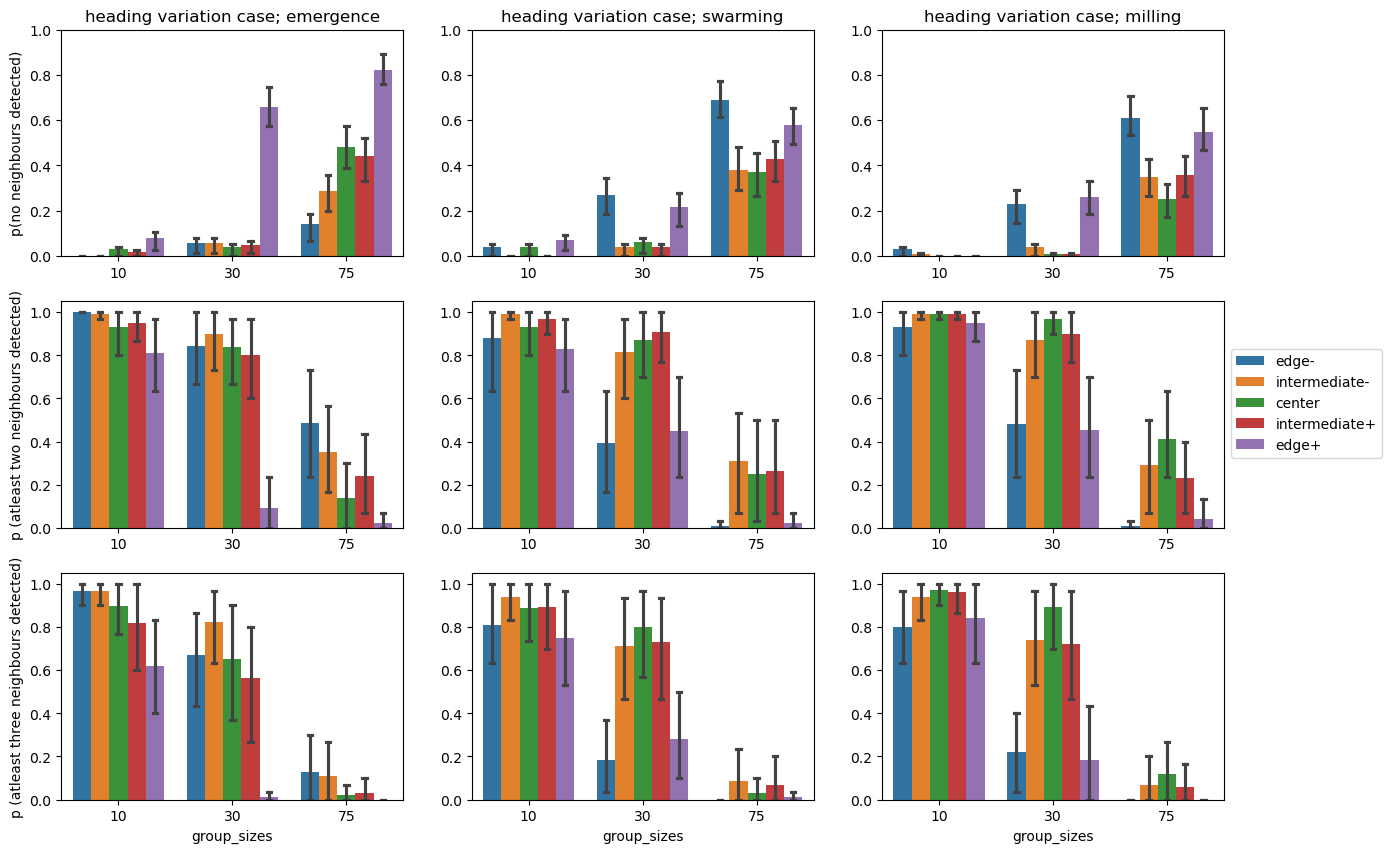

In [17]:
import seaborn as sns
df = pd.DataFrame(probabilities)
i=1
plt.figure(figsize=(15,10))
heading_vars= ["emergence", "swarming", "milling"]
for heading_var in heading_vars:
    plt.subplot(3,3, i)
    sns.barplot(data=df.loc[df["heading_variations"]==heading_var], x="group_sizes", y="probability no neighbour detected", hue="position", hue_order=["edge-", "intermediate-", "center", "intermediate+", "edge+"], errorbar=("pi",100), capsize=0.2)
    plt.ylim(0,1)
    plt.title(f"heading variation case; {heading_var}")
    plt.ylabel("p(no neighbours detected)")
    plt.xlabel("")
    if i%3!=1:
        plt.ylabel("")
    plt.legend().remove()
    i+=1
for heading_var in heading_vars:
    plt.subplot(3,3, i)
    sns.barplot(data=df.loc[df["heading_variations"]==heading_var], x="group_sizes", y="probability of atleast two neighbour detected", hue="position", hue_order=["edge-", "intermediate-", "center", "intermediate+", "edge+"], errorbar=("pi",100), capsize=0.2)
    plt.ylabel("p (atleast two neighbours detected)")
    plt.xlabel("")
    if i%3!=1:
        plt.ylabel("")
    plt.legend().remove()
    i+=1
for heading_var in heading_vars:
    plt.subplot(3,3, i)
    sns.barplot(data=df.loc[df["heading_variations"]==heading_var], x="group_sizes", y="probability of atleast three neighbour detected", hue="position", hue_order=["edge-", "intermediate-", "center", "intermediate+", "edge+"], errorbar=("pi",100), capsize=0.2)
    plt.ylabel("p (atleast three neighbours detected)")
    if i%3!=1:
        plt.ylabel("")
    plt.legend().remove()
    i+=1
plt.legend(loc="center left", bbox_to_anchor=(1, 1.75))
plt.show()

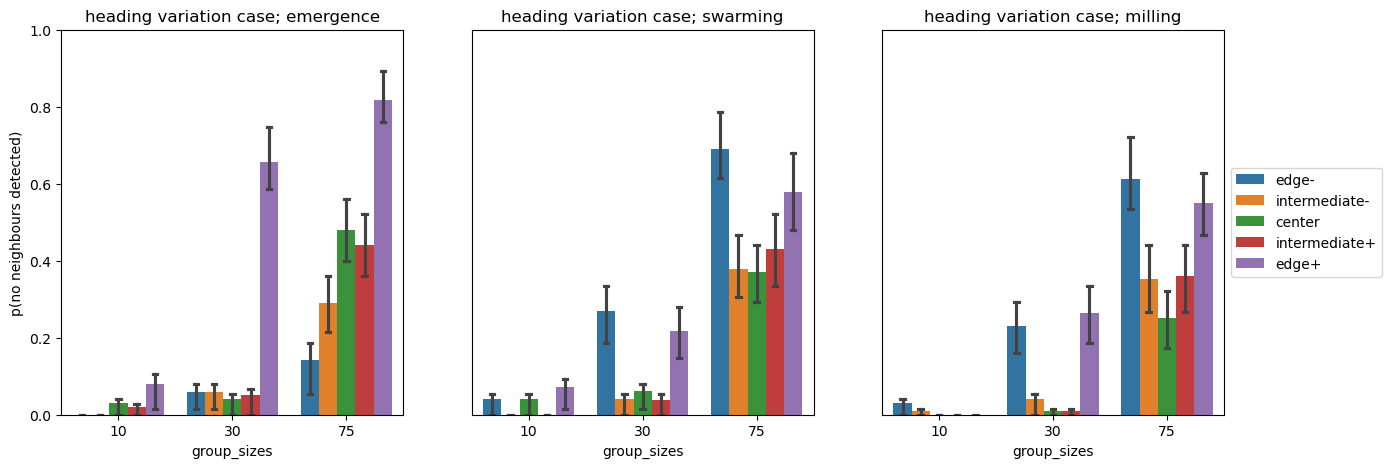

In [ ]:
import seaborn as sns
plt.style.use("default")
df = pd.DataFrame(probabilities)
i=1
plt.figure(figsize=(15,5))
heading_vars= ["emergence", "swarming", "milling"]
for heading_var in heading_vars:
    plt.subplot(1,3, i)
    sns.barplot(data=df.loc[df["heading_variations"]==heading_var], x="group_sizes", y="probability no neighbour detected", hue="position", hue_order=["edge-", "intermediate-", "center", "intermediate+", "edge+"], errorbar=("pi",100), capsize=0.2)
    plt.ylim(0,1)
    plt.title(f"heading variation case; {heading_var}")
    plt.ylabel("p(no neighbours detected)")
    # plt.xlabel("")
    
    if i%3!=1:
        plt.ylabel("")
        plt.yticks([])
    plt.legend().remove()
    i+=1

plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

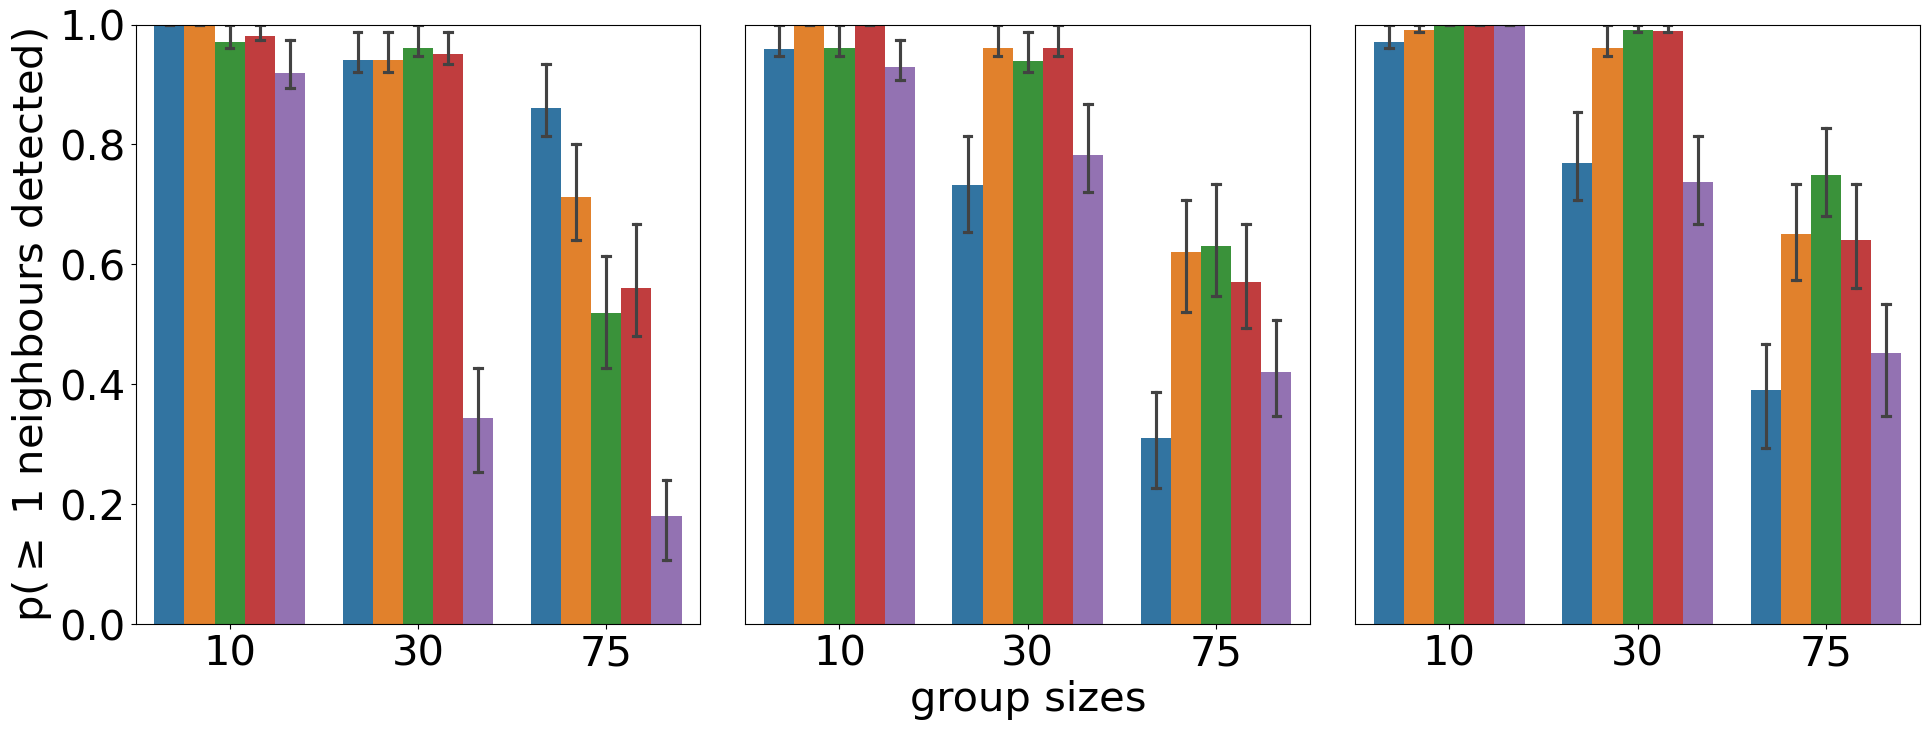

In [25]:
import seaborn as sns


plt.rcParams['font.size'] = '30'
df = pd.DataFrame(probabilities)
i=1
plt.figure(figsize=(20,8))
heading_vars= ["emergence", "swarming", "milling"]
for heading_var in heading_vars:
    plt.subplot(1,3, i)
    sns.barplot(data=df.loc[df["heading_variations"]==heading_var], x="group_sizes", y="probability of atleast one neighbour detected", hue="position", hue_order=["edge-", "intermediate-", "center", "intermediate+", "edge+"], errorbar=("pi",100), capsize=0.2)
    plt.ylim(0,1)
    # plt.title(f"{heading_var}")
    plt.ylabel("p($\geq$ 1 neighbours detected)")
    plt.xlabel("")
    
    if i%3!=1:
        plt.ylabel("")
        # plt.grid(True)
        plt.yticks([])
    if i%3==2:
        plt.xlabel("group sizes")
    
    i+=1
    plt.legend().remove()
plt.tight_layout()
# plt.grid()


# plt.supxlabel("xaxis")
# plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

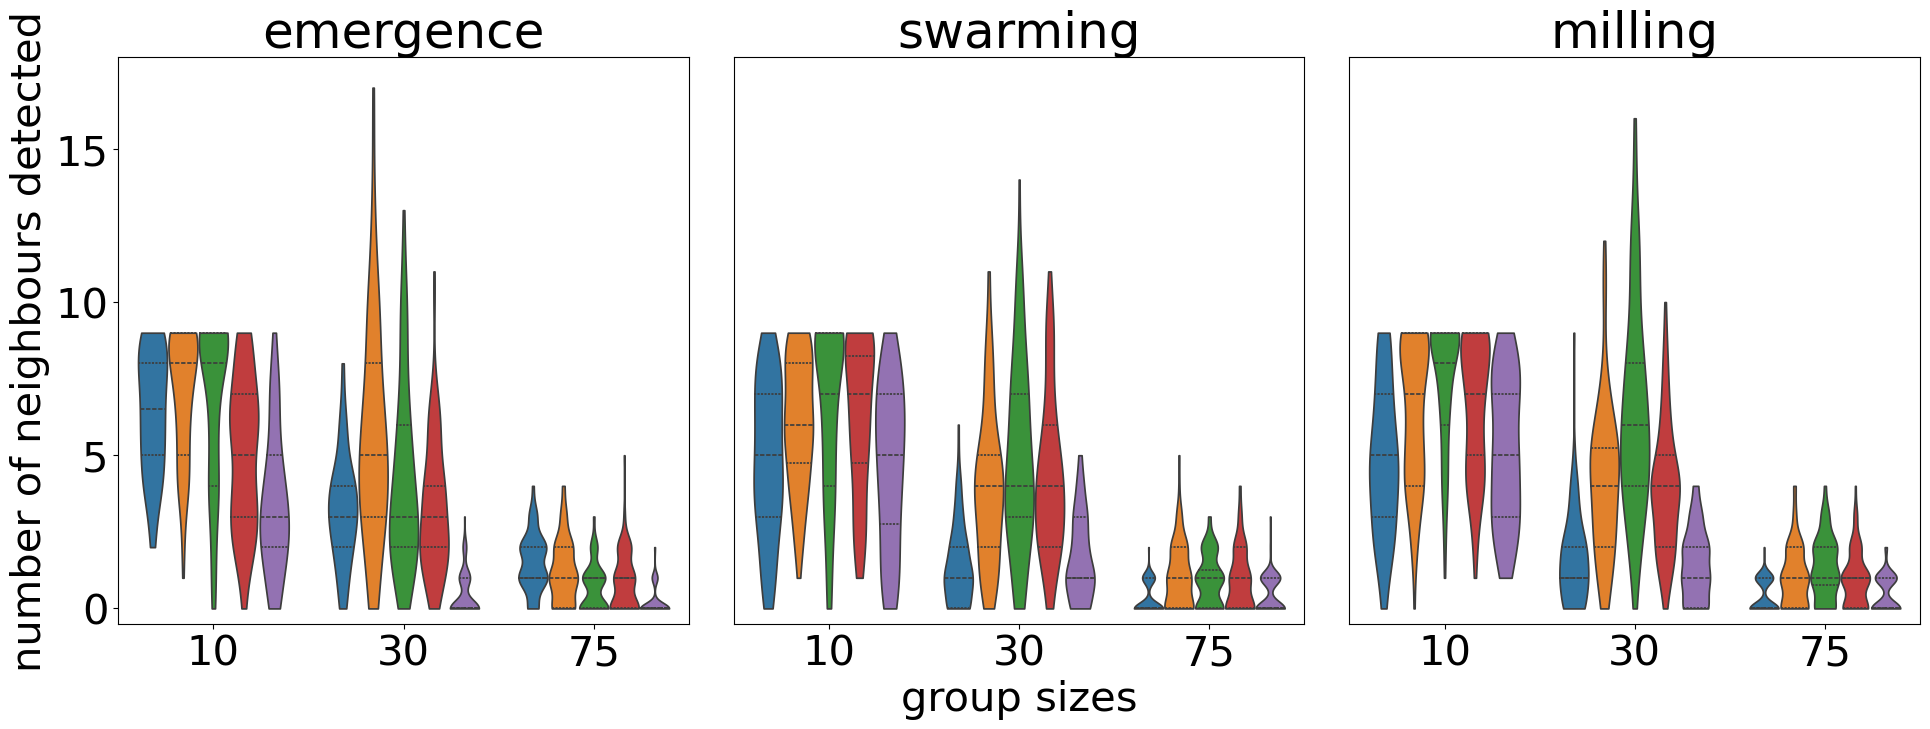

In [19]:
import seaborn as sns
plt.rcParams['font.size'] = '30'
df = pd.DataFrame(number_of_neighbours_detected)
i=1
plt.figure(figsize=(20,8))
heading_vars= ["emergence", "swarming", "milling"]
for heading_var in heading_vars:
    plt.subplot(1,3, i)
    sns.violinplot(data=df.loc[df["heading_variations"]==heading_var], x="group_sizes", y="response_variable", hue="position", hue_order=["edge-", "intermediate-", "center", "intermediate+", "edge+"], inner="quart", cut=0, gap=0.05,
                   density_norm="width")
    plt.ylim(-0.5, 18)
    plt.ylabel("number of neighbours detected")
    plt.title(f"{heading_var}")
    # plt.ylabel("p($\geq$ 1 neighbours detected)")
    plt.xlabel("")
    
    if i%3!=1:
        plt.ylabel("")
        plt.yticks([])
    if i%3==2:
        plt.xlabel("group sizes")
    plt.legend().remove()
    i+=1
plt.tight_layout()
# plt.supxlabel("xaxis")
# plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

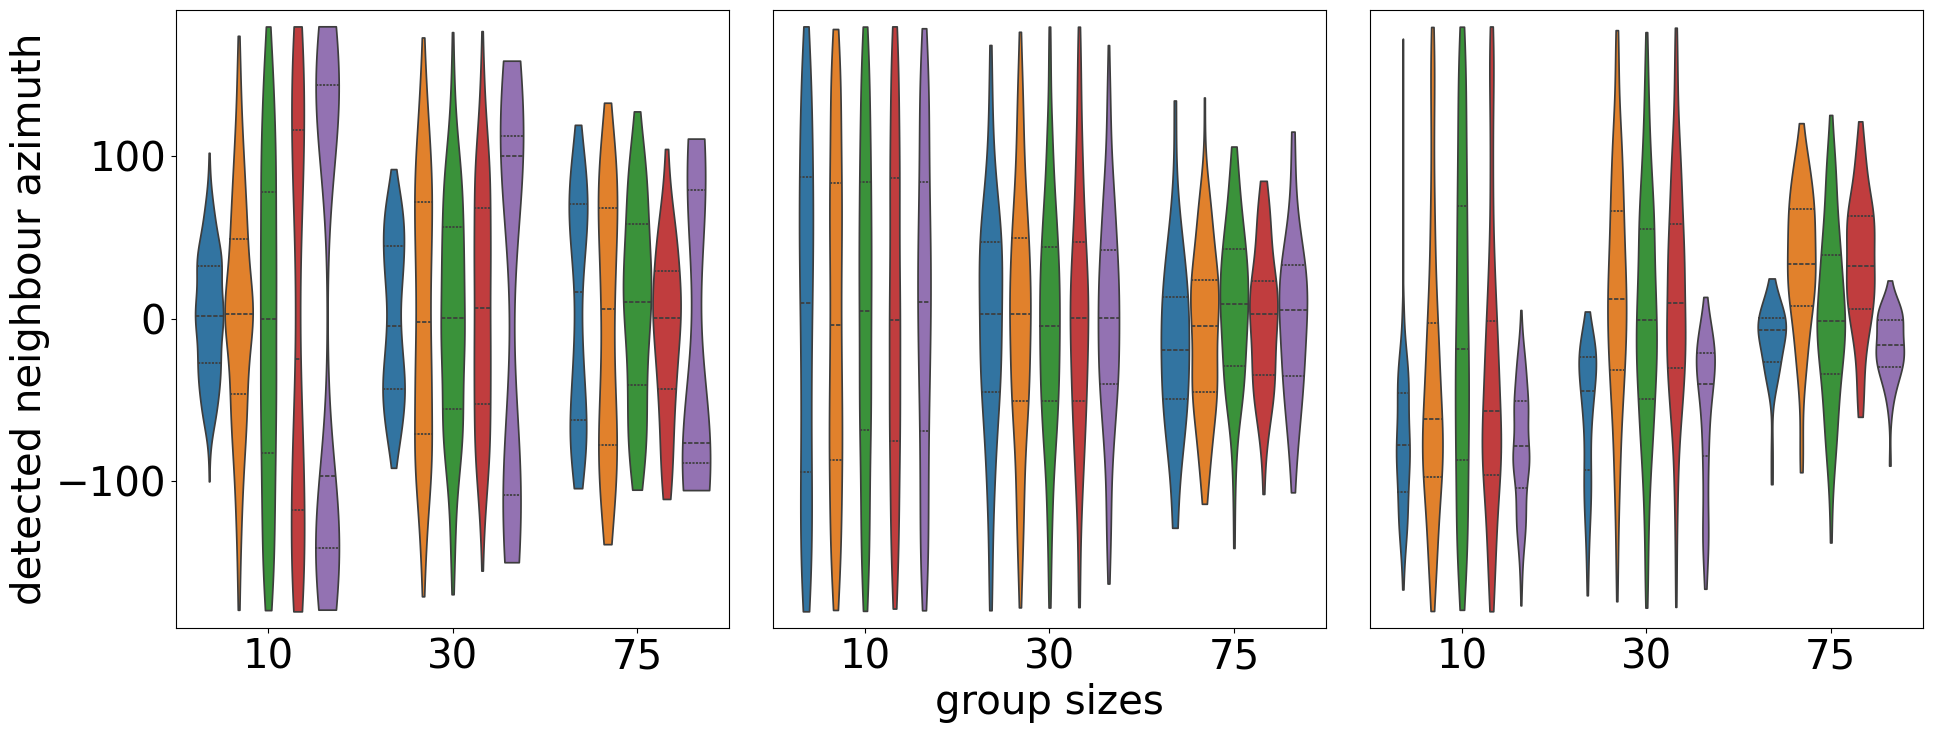

In [26]:
import seaborn as sns
plt.rcParams['font.size'] = '29'
df = pd.DataFrame(neighbour_azimunth)
i=1
plt.figure(figsize=(20,8))
heading_vars= ["emergence", "swarming", "milling"]
for heading_var in heading_vars:
    plt.subplot(1,3, i)
    sns.violinplot(data=df.loc[df["heading_variations"]==heading_var], x="group_sizes", y="response_variable", hue="position", hue_order=["edge-", "intermediate-", "center", "intermediate+", "edge+"], inner="quart", cut=0, gap=0.05
                   )
    plt.ylim(-190, 190)
    plt.ylabel("detected neighbour azimuth")
    # plt.title(f"{heading_var}")
    # plt.ylabel("p($\geq$ 1 neighbours detected)")
    plt.xlabel("")
    
    if i%3!=1:
        plt.ylabel("")
        plt.yticks([])
    if i%3==2:
        plt.xlabel("group sizes")
    plt.legend().remove()
    i+=1
plt.tight_layout()
# plt.supxlabel("xaxis")
# plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

In [ ]:
group_sizes

[10, 30, 75]

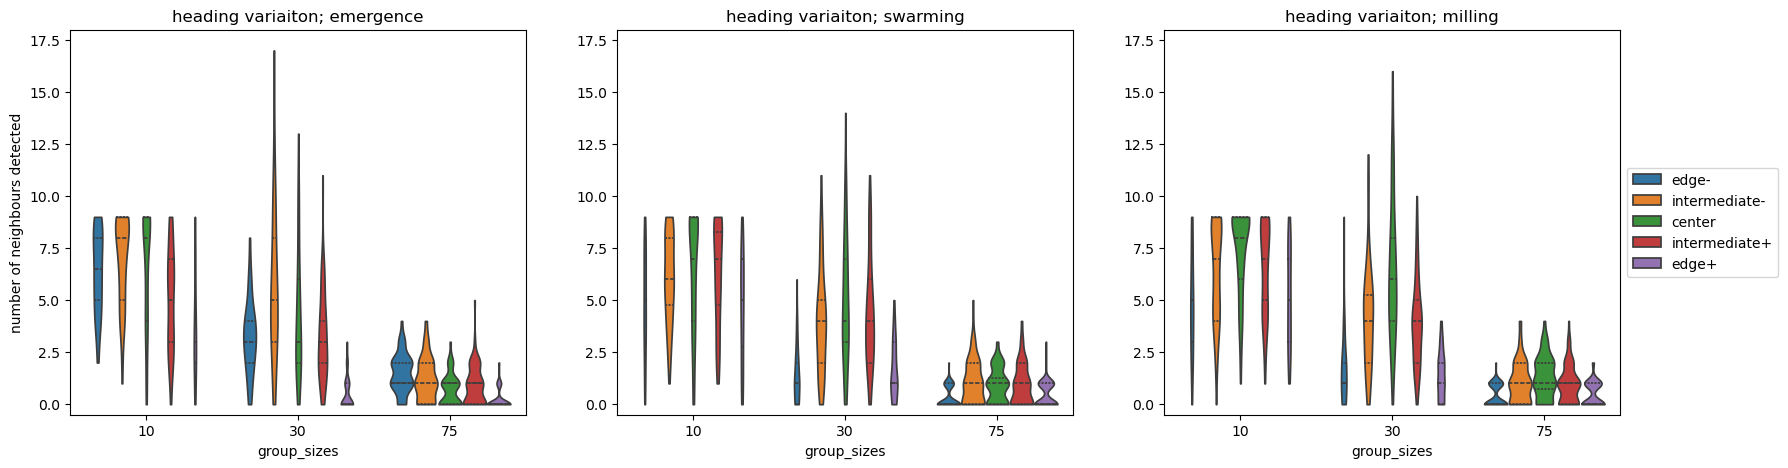

In [ ]:
df = pd.DataFrame(number_of_neighbours_detected)
i=1
plt.figure(figsize=(20,5))
for heading_var in heading_vars:
    plt.subplot(1,3, i)
    sns.violinplot(data=df.loc[df["heading_variations"]==heading_var], x="group_sizes", y="response_variable", hue="position", hue_order=["edge-", "intermediate-", "center", "intermediate+", "edge+"], inner="quart", cut=0, gap=0.05)
    plt.legend().remove()
    plt.ylim(-0.5, 18)
    plt.ylabel("number of neighbours detected")
    plt.title(f"heading variaiton; {heading_var}")
    if i%3!=1:
        plt.ylabel("")
    i+=1
# for heading_var in group_heading_variation:
#     plt.subplot(3,3, i)
#     sns.barplot(data=df.loc[df["heading_variations"]==heading_var], x="group_sizes", y="response_variable", hue="position", hue_order=["edge-", "intermediate-", "center", "intermediate+", "edge+"], errorbar=("pi",100), capsize=0.2)
#     plt.ylabel("p (atleast two neighbours)")
#     plt.legend().remove()
#     i+=1
# for heading_var in group_heading_variation:
#     plt.subplot(3,3, i)
#     sns.barplot(data=df.loc[df["heading_variations"]==heading_var], x="group_sizes", y="response_variable", hue="position", hue_order=["edge-", "intermediate-", "center", "intermediate+", "edge+"], errorbar=("pi",100), capsize=0.2)
#     plt.ylabel("p (atleast three neighbours)")
#     plt.legend().remove()
#     i+=1
# plt.ylim(-2.5, 20)
plt.legend(loc="center left", bbox_to_anchor=(1, .5))
plt.show()

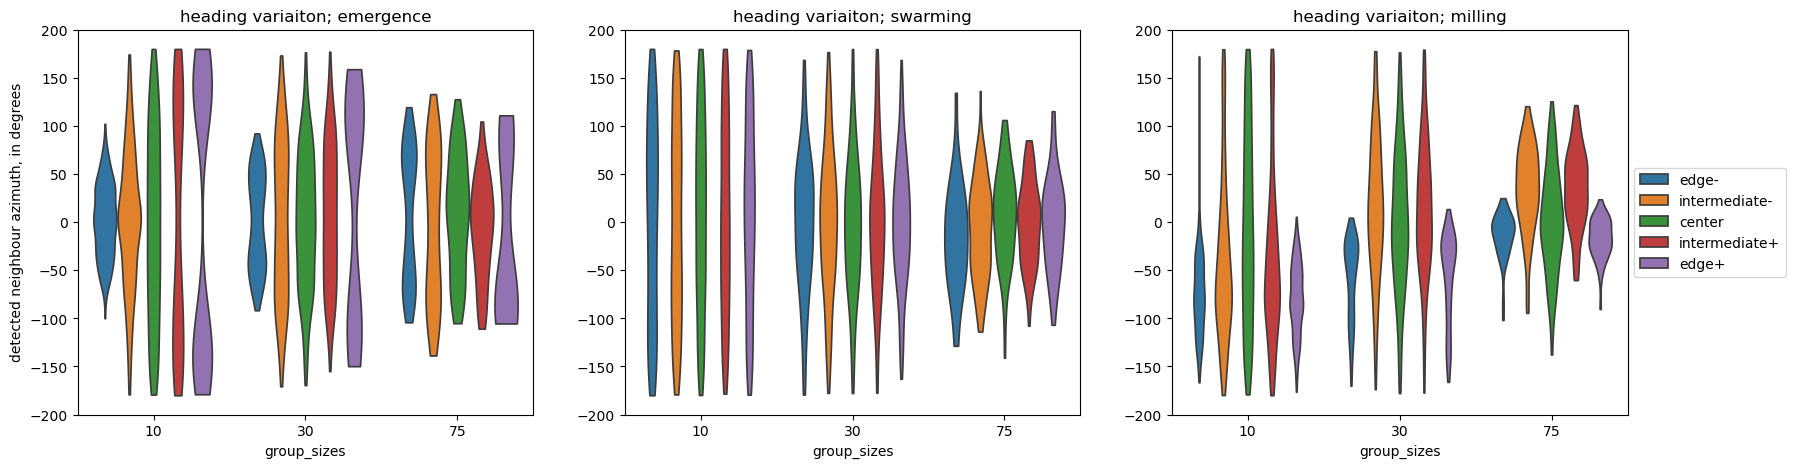

In [ ]:
df = pd.DataFrame(neighbour_azimunth)
i=1
plt.figure(figsize=(20,5))
for heading_var in heading_vars:
    plt.subplot(1,3, i)
    sns.violinplot(data=df.loc[df["heading_variations"]==heading_var], x="group_sizes", y="response_variable", hue="position", hue_order=["edge-", "intermediate-", "center", "intermediate+", "edge+"], inner=None, cut=0, gap=0.05)
    plt.legend().remove()
    plt.ylim(-200, 200)
    plt.ylabel("detected neighbour azimuth, in degrees")
    plt.title(f"heading variaiton; {heading_var}")
    if i%3!=1:
        plt.ylabel("")
    i+=1

plt.legend(loc="center left", bbox_to_anchor=(1, .5))
plt.show()

[]


/tmp/ipykernel_305927/2245070400.py:14: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  set_of_all_points= np.row_stack((focal, nearby))


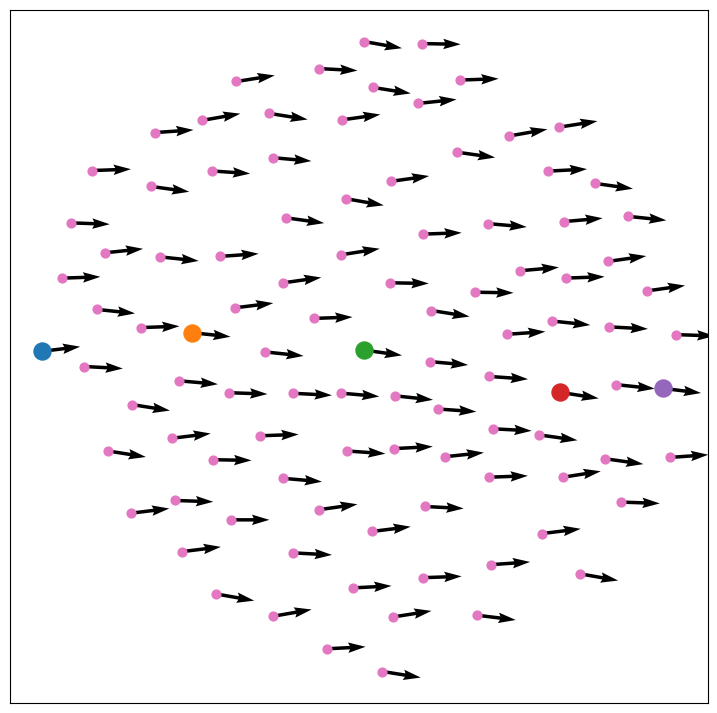

In [ ]:
sys.path.append('../CPN/')
import the_cocktail_party_nightmare as CPN
import matplotlib.pyplot as plt
import numpy as np
from create_milling_swarming_angles import generate_heading_vectors_concentric_circles, generate_heading_vectors_random_all_angles
from generate_focal_bat_given_d import generate_subset_of_points_given_d
import math

colors_for_position = sns.color_palette()[0:8]

np.random.seed(78464)
sim_data={}; sim_data["noncentral_bat"]=False; sim_data["Nbats"]=100
nearby, focal= CPN.generate_surroundpoints_w_poissondisksampling(npoints=100, nbr_distance=0.5, **sim_data)
set_of_all_points= np.row_stack((focal, nearby))
# vector_angles= generate_heading_vectors_concentric_circles(set_of_all_points=set_of_all_points, resolution=32)
# vector_angles = generate_heading_vectors_random_all_angles(**sim_data)
min_heading, max_heading = 0 - 10, 0 + 10
vector_angles = np.random.choice(np.arange(min_heading, max_heading+1),100)
        
points_edge_positive= generate_subset_of_points_given_d(nearby, focal, 2, 0.5, np.pi/2, 0.1)
print(points_edge_positive[0])

def compute_u_v_for_plotting(points, angles):
    u_v_s= []; i=0
    for angle in angles:
        point= points[i]
        angle_in_radians= math.radians(angle)
        U= np.cos(angle_in_radians)
        V= np.sin(angle_in_radians)
        
        u_v_s.append([point[0], point[1], U, V])
        i+=1

    return np.array(u_v_s)

u_v_s= compute_u_v_for_plotting(set_of_all_points, vector_angles)

plt.figure(figsize= (9,9))

for u_v in u_v_s:
    plt.quiver(*u_v, width = 0.005)

edge_plus = [8.60995243, 4.7811467] 
edge_minus = [1.68284201, 5.19780943]
intermediate_plus = [7.47034483, 4.73583187]
intermediate_minus = [3.35988296, 5.408313  ]


plt.scatter(nearby[:,0], nearby[:,1], color = colors_for_position[6], s=40)
plt.scatter(edge_minus[0], edge_minus[1], label="edge-", color= colors_for_position[0], s= 150)
plt.scatter(intermediate_minus[0], intermediate_minus[1], label="intermediate-", color= colors_for_position[1], s= 150)
plt.scatter(focal[0], focal[1], label="center", color= colors_for_position[2], s= 150)
plt.scatter(intermediate_plus[0], intermediate_plus[1], label="intermediate+", color= colors_for_position[3], s= 150)
plt.scatter(edge_plus[0], edge_plus[1], label="edge+", color= colors_for_position[4], s= 150)
# plt.legend()
plt.xticks([])
plt.yticks([])
# plt.savefig("analysis/plots_for_poster/emergence10.png")
plt.show()

# i=0
# while i<100:
#     nearby, focal= CPN.generate_surroundpoints_w_poissondisksampling(npoints=100, nbr_distance=0.5, **sim_data)
#     set_of_all_points= np.row_stack((focal, nearby))
#     vector_angles= generate_heading_vectors_concentric_circles(set_of_all_points=set_of_all_points, resolution=3)
#     u_v_s= compute_u_v_for_plotting(set_of_all_points, vector_angles)
#     # plt.scatter(focal[0], focal[1])
#     plt.quiver(0,0,*u_v_s[0][2:])
#     i+=1
# plt.show()

In [ ]:
nearby[np.argmin(nearby[:,0])]
nearby[np.argmax(nearby[:,0])]
focal

array([5.27468397, 5.21327926])

In [ ]:
[i for i in nearby if i[1]<5.6 and i[1]>4.5]

[array([5.01837453, 4.72714075]),
 array([5.61911608, 4.69693984]),
 array([4.71824925, 5.56953549]),
 array([6.00955499, 5.08246378]),
 array([4.48933881, 4.72522062]),
 array([6.1009344 , 4.54810139]),
 array([4.17469805, 5.19161073]),
 array([6.67783218, 4.91502348]),
 array([3.76933982, 4.73180133]),
 array([6.87062246, 5.38995037]),
 array([3.35988296, 5.408313  ]),
 array([3.21805157, 4.86558075]),
 array([7.37341735, 5.54028172]),
 array([7.47034483, 4.73583187]),
 array([2.78782889, 5.46613336]),
 array([2.68661261, 4.5983563 ]),
 array([8.01501652, 5.47382331]),
 array([8.09227971, 4.82269643]),
 array([2.15662661, 5.0271479 ]),
 array([8.60995243, 4.7811467 ]),
 array([8.75727712, 5.38690848]),
 array([1.68284201, 5.19780943])]

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354)]